[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Batch Normalization

Two notebooks ago we watched LeNet sit at chance accuracy for several epochs
before it began to learn, and blamed the sigmoid: saturated units have nearly
zero gradient, so nothing reaches the early layers.  ReLU fixed that instance of
the problem, and AlexNet trained without a plateau.

But the underlying difficulty is more general than one activation function, and
it gets worse the deeper a network goes.  This notebook is about the technique
that made networks of a hundred layers trainable:

> Ioffe, S., & Szegedy, C. (2015). Batch normalization: accelerating deep
> network training by reducing internal covariate shift. *International
> Conference on Machine Learning*.

**Batch normalization** is worth your attention for three reasons.  It is
everywhere — ResNet in the next notebook does not work without it.  It is the
first technique we have met that behaves *differently during training and
prediction*, which explains what `model.train()` and `model.eval()` have been
doing all along.  And its close relative, **layer normalization**, is the
normalization used in every transformer you have seen; we passed over it quickly
in module 04, and this is where it gets explained properly.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import time

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using {device} device')

Using mps device


## The problem

Start with something you already do without thinking.  Before training any model
on real data, you standardize the inputs: subtract the mean, divide by the
standard deviation.  Nobody argues about this.  If one input feature is measured
in millimetres and another in kilometres, a single learning rate cannot suit
both — the loss surface is a long thin valley, and gradient descent bounces
across it instead of running down it.

Now notice that **every layer of a deep network is a model whose inputs are the
layer below's outputs**, and nobody standardized those.  Worse, they are not
fixed: the layer below is being trained, so the distribution of its outputs
drifts from step to step.  Layer 12 spends its time chasing a moving target.

Let's look at what actually happens.  We take an untrained network with sigmoid
activations, push a batch through it, and record the scale of the activations
and of the gradients at each depth.

In [3]:
torch.manual_seed(0)

def activation_scales(depth=12, width=256, batch=256):
    """Standard deviation of activations and gradients at each layer."""
    layers = []
    for _ in range(depth):
        layers += [nn.Linear(width, width), nn.Sigmoid()]
    net = nn.Sequential(*layers)

    X = torch.randn(batch, width)
    activations = []
    for layer in net:
        X = layer(X)
        if isinstance(layer, nn.Sigmoid):
            X.retain_grad()
            activations.append(X)

    # a random covector, so the top layer's gradient is not artificially uniform
    (activations[-1] * torch.randn_like(activations[-1])).sum().backward()
    return ([a.std().item() for a in activations],
            [a.grad.std().item() for a in activations])

act, grad = activation_scales()
print(f'{"layer":>6s} {"activation std":>16s} {"gradient std":>16s}')
print('-' * 40)
for i, (a, g) in enumerate(zip(act, grad), start=1):
    print(f'{i:>6d} {a:>16.4f} {g:>16.3e}')

 layer   activation std     gradient std
----------------------------------------
     1           0.1336        4.365e-10
     2           0.0765        3.085e-09
     3           0.0722        2.188e-08
     4           0.0740        1.553e-07
     5           0.0712        1.099e-06
     6           0.0658        7.771e-06
     7           0.0725        5.561e-05
     8           0.0734        3.934e-04
     9           0.0757        2.809e-03
    10           0.0696        1.993e-02
    11           0.0723        1.414e-01
    12           0.0728        1.002e+00


Two things go wrong at once, and they are the same thing seen from opposite
ends.

Going *up*, the activations collapse.  Each sigmoid squashes its input into
$(0,1)$, and within two layers the standard deviation across units has fallen to
about 0.07 and stays there — every unit is sitting near 0.5, saying almost the
same thing as every other unit.  Whatever distinctions the input contained have
been compressed into a narrow band.

Going *down* is worse.  The gradient shrinks by a roughly constant factor at each
layer, and over twelve layers that compounds into eight or nine orders of
magnitude: the gradient reaching layer 1 is roughly a billionth of the gradient at
the top.  A single learning rate cannot serve both ends of that range.  Whatever step
size makes the top of the network learn at a reasonable pace leaves the bottom
frozen.

This is the vanishing gradient of notebook 06_06, now visible as a table rather
than as a flat spot in a training curve.  And notice that it is fundamentally a
problem about *scale*: no layer is computing anything wrong, they are simply
operating at wildly different magnitudes.

The obvious response is the one we already apply to the input.  If standardizing
the data helps, standardize the activations too — not once, but at every layer,
continuously, as part of the network.

## The definition

For a minibatch $\mathcal{B}$, batch normalization computes

$$\mathrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot
\frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}
     {\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}$$

where $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and
$\hat{\boldsymbol{\sigma}}_\mathcal{B}$ are the mean and standard deviation of
the values in the minibatch, and $\odot$ is elementwise multiplication.  In
practice the variance gets a small $\epsilon$ added before the square root, so
that a feature which happens to be constant across the batch does not divide by
zero.

The first part is just standardization.  The interesting part is
$\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$: a learned scale and a learned
shift, applied *after* the normalization.

Why undo the work you just did?  Because forcing every layer's output to have
mean 0 and variance 1 is a strong constraint, and not always the right one — a
sigmoid's useful range is around zero, but a ReLU that never sees a positive
input is dead.  With $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$ the layer can
learn whatever mean and scale suit it, including recovering the unnormalized
values exactly.  What normalization removes is the *coupling*: the scale is now
set by two parameters trained directly for the purpose, instead of emerging
uncontrolled from the product of everything below.

Note also that $\hat{\boldsymbol{\mu}}_\mathcal{B}$ is computed from the batch,
so it depends on which other examples happen to be in it.  That is a genuinely
odd property for a layer to have — the network's output for your image depends
on the fifteen unrelated images beside it — and it is the source of both batch
normalization's side benefits and its problems.  We come back to it.

## Which values get averaged together?

The definition says "the mean over the minibatch", but over which axes?  The
answer differs between fully connected and convolutional layers, and the
convolutional case follows directly from the principles of notebook 06_02.

For a **fully connected** layer, the activations are `(batch, features)` and we
normalize each feature separately, averaging over the batch axis.  Each of the
features is a different quantity, so each gets its own mean and variance, and
$\boldsymbol{\gamma}, \boldsymbol{\beta}$ have one entry per feature.

For a **convolutional** layer, the activations are
`(batch, channels, height, width)`, and we normalize per *channel*, averaging
over batch, height and width together.  The reason is weight sharing: a channel
is one feature detector applied at every spatial position, so all
$n \cdot h \cdot w$ of its outputs are measurements of the same quantity.  Giving
each position its own mean would break the translation invariance we spent
notebook 06_02 deriving.  So $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$ have
one entry per channel, not per pixel.

In [4]:
X = torch.randn(64, 16, 28, 28)      # (batch, channels, height, width)

bn_mean = X.mean(dim=(0, 2, 3))      # batch normalization: one mean per channel
ln_mean = X.mean(dim=(1, 2, 3))      # layer normalization: one mean per example

print(f'activations           {tuple(X.shape)}')
print(f'batch norm statistics {tuple(bn_mean.shape)}  '
      f'one per channel, averaged over {X.shape[0] * X.shape[2] * X.shape[3]:,d} values')
print(f'layer norm statistics {tuple(ln_mean.shape)}  '
      f'one per example, averaged over {X.shape[1] * X.shape[2] * X.shape[3]:,d} values')

activations           (64, 16, 28, 28)
batch norm statistics (16,)  one per channel, averaged over 50,176 values
layer norm statistics (64,)  one per example, averaged over 12,544 values


Layer normalization appears in that cell without introduction; hold on to it for
a moment, because the contrast is best drawn as a picture.  Below, the same block
of activations twice — rows are examples in the batch, columns are channels, and
each cell is one channel's feature map for one example.  The shaded region is
what gets averaged to produce a single mean and variance.

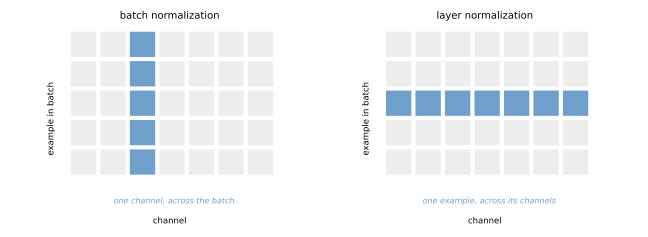

In [ ]:
def normalization_axis_figure():
    """A block of activations twice: batch normalization averages down a
    column, layer normalization across a row."""
    n_examples, n_channels = 5, 7
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
    panels = [('batch normalization', 'column', 'one channel, across the batch'),
              ('layer normalization', 'row', "one example, across its channels")]
    for ax, (title, kind, note) in zip(axes, panels):
        for i in range(n_examples):
            for j in range(n_channels):
                shaded = ((kind == 'column' and j == 2) or
                          (kind == 'row' and i == 2))
                ax.add_patch(plt.Rectangle(
                    (j, n_examples - 1 - i), 0.86, 0.86, edgecolor='none',
                    facecolor='#6f9fcb' if shaded else '#ededed'))
        ax.set_xlim(-0.4, n_channels + 0.1)
        ax.set_ylim(-1.3, n_examples + 0.1)
        ax.set_xlabel('channel', fontsize=8.5)
        ax.set_ylabel('example in batch', fontsize=8.5)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal')
        ax.text(n_channels / 2, -0.9, note, ha='center', va='center',
                fontsize=8, style='italic', color='#6f9fcb')
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.tight_layout()


normalization_axis_figure()

**Batch normalization takes a column**: one channel, across every example in the
batch.  **Layer normalization takes a row**: one example, across every channel.
Same tensor, perpendicular slices.

That difference is not cosmetic.  A column crosses examples, so the statistics
depend on what else is in the batch; a row does not, so layer normalization
treats each example completely independently.  We will see in a moment why
transformers need that and convolutional networks do not.

## Implementing it

Here is batch normalization written out, handling both the two-dimensional and
four-dimensional cases.  The `training` flag selects between the two behaviours,
and the `moving_mean` and `moving_var` arguments are the running estimates used
when predicting; both are explained just below.

In [6]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum, training):
    """Batch-normalize X: batch statistics when training, running ones when predicting."""
    if not training:
        # prediction: use the running estimates accumulated during training
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # fully connected: one statistic per feature
            dims = (0,)
        else:
            # convolutional: one statistic per channel, over batch and space
            dims = (0, 2, 3)
        mean = X.mean(dim=dims, keepdim=True)
        var = ((X - mean) ** 2).mean(dim=dims, keepdim=True)
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # accumulate the running estimates for use at prediction time.  PyTorch
        # uses the unbiased variance here and the biased one above; the
        # difference is a factor of n/(n-1) and is negligible in practice.
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    return gamma * X_hat + beta, moving_mean.data, moving_var.data

## Training and prediction are different

Every layer we have written so far computes the same function whether we are
training or predicting.  Batch normalization cannot.

At training time the mean and variance come from the minibatch.  At prediction
time that is not available and not wanted: predictions would depend on which
other examples you happened to submit alongside, and classifying a single image
would be impossible, since one example has zero variance.

So batch normalization keeps a **running estimate** of the mean and variance,
updated during training as an exponential moving average, and uses those fixed
values at prediction time.  They are part of the model's state but they are not
parameters — no gradient ever touches them.  In PyTorch they are registered as
*buffers*: saved in the `state_dict`, moved between devices with the model, but
invisible to the optimizer.

Every `nn.Module` carries a `self.training` flag, and `model.train()` and
`model.eval()` are simply the methods that set it on every submodule.  Our
implementation reads that flag; note that it would be a mistake to test whether
gradients are enabled instead, since evaluating a model inside `torch.no_grad()`
and evaluating it outside must give the same answer.

It is worth being clear that you have been calling these two methods all along
without much consequence.  Until
now their only effect was on dropout.  With batch normalization the difference
matters far more: a model left in `train()` mode during evaluation normalizes
each validation batch by its own statistics, which quietly leaks information
across the batch and inflates your accuracy.  It is one of the most common bugs
in deep learning code, and it produces results that look *good*, which is the
worst kind of bug.

In [7]:
class BatchNorm(nn.Module):
    """Batch normalization for fully connected (num_dims=2) or convolutional (4) layers."""
    def __init__(self, num_features, num_dims):
        super().__init__()
        shape = (1, num_features) if num_dims == 2 else (1, num_features, 1, 1)
        # learned scale and shift -- these are parameters
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # running statistics -- state, but not parameters, so registered as buffers
        self.register_buffer('moving_mean', torch.zeros(shape))
        self.register_buffer('moving_var', torch.ones(shape))

    def forward(self, X):
        # self.training is the flag that model.train() and model.eval() set
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean, self.moving_var,
            eps=1e-5, momentum=0.1, training=self.training)
        return Y

## The experiment: LeNet, with and without

The clearest demonstration is the one closest to hand.  Notebook 06_06 trained
LeNet exactly as published — sigmoid activations, average pooling — and spent
several epochs at chance accuracy before the loss began to fall.  We attributed
the plateau to saturating sigmoids.

If batch normalization does what it claims, inserting it after each convolution
and each dense layer should remove that plateau **without touching the
activation function**.  The sigmoids are still there, still saturating; what
changes is that their inputs arrive at a controlled scale.

Fashion-MNIST at its native $28 \times 28$, so both runs take a couple of minutes
rather than an hour.

In [8]:
batch_size = 128
data_dir = '../data'
transform = transforms.ToTensor()

train_set = datasets.FashionMNIST(data_dir, train=True, download=True,
                                  transform=transform)
val_set = datasets.FashionMNIST(data_dir, train=False, download=True,
                                transform=transform)
train_iter = DataLoader(train_set, batch_size, shuffle=True)
val_iter = DataLoader(val_set, batch_size)

labels = train_set.classes
print(f'{len(train_set)} training and {len(val_set)} validation images, '
      f'shape {tuple(train_set[0][0].shape)}')

60000 training and 10000 validation images, shape (1, 28, 28)


In [9]:
def make_lenet(batch_normalized=False, num_classes=10):
    """LeNet-5 as published, optionally with batch normalization after each layer."""
    def bn(num_features, num_dims):
        return [BatchNorm(num_features, num_dims)] if batch_normalized else []

    return nn.Sequential(
        nn.LazyConv2d(6, kernel_size=5, padding=2), *bn(6, 4), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.LazyConv2d(16, kernel_size=5), *bn(16, 4), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.LazyLinear(120), *bn(120, 2), nn.Sigmoid(),
        nn.LazyLinear(84), *bn(84, 2), nn.Sigmoid(),
        nn.LazyLinear(num_classes))

print(make_lenet(batch_normalized=True))

Sequential(
  (0): LazyConv2d(0, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): BatchNorm()
  (2): Sigmoid()
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): LazyConv2d(0, 16, kernel_size=(5, 5), stride=(1, 1))
  (5): BatchNorm()
  (6): Sigmoid()
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): LazyLinear(in_features=0, out_features=120, bias=True)
  (10): BatchNorm()
  (11): Sigmoid()
  (12): LazyLinear(in_features=0, out_features=84, bias=True)
  (13): BatchNorm()
  (14): Sigmoid()
  (15): LazyLinear(in_features=0, out_features=10, bias=True)
)


Note where the normalization goes: *after* the linear or convolutional
operation and *before* the activation.  That is where Ioffe and Szegedy put it,
and it is the order that makes sense — the point is to control what the
nonlinearity sees.

Two details of the arrangement are worth naming.  The convolutional layers keep
their biases here, but in production code they are usually turned off
(`bias=False`) whenever batch normalization follows, since $\boldsymbol{\beta}$
supplies a shift already and the bias is redundant.  And with batch
normalization present, Xavier initialization matters much less: the layer fixes
the scale on every forward pass regardless of where the weights started.

In [10]:
def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    return (Y_hat.argmax(dim=1) == Y).float().mean()

def train(model, epochs=15, lr=0.1, quiet=False):
    """Train a model, returning per-epoch training loss and validation accuracy."""
    model = model.to(device)
    model(next(iter(train_iter))[0].to(device))     # materialize the Lazy layers
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loss_train, accuracy_valid = [], []

    for epoch in range(epochs):
        start = time.time()
        model.train()
        loss_values = []
        for batch_X, batch_y in train_iter:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            loss = loss_fn(model(batch_X), batch_y)
            loss_values.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        loss_train.append(np.mean(loss_values))

        model.eval()
        accuracy_values = []
        for batch_X, batch_y in val_iter:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            with torch.no_grad():
                accuracy_values.append(accuracy(model(batch_X), batch_y).item())
        accuracy_valid.append(np.mean(accuracy_values))

        if not quiet:
            print(f'epoch {epoch + 1:2d}  train loss {loss_train[-1]:.3f}  '
                  f'val accuracy {accuracy_valid[-1]:.3f}  '
                  f'({time.time() - start:.1f} s)')
    return model, loss_train, accuracy_valid

In [11]:
torch.manual_seed(0)
print('LeNet, as published')
plain_model, plain_loss, plain_acc = train(make_lenet(batch_normalized=False))

print()
torch.manual_seed(0)
print('LeNet, with batch normalization')
bn_model, bn_loss, bn_acc = train(make_lenet(batch_normalized=True))

LeNet, as published
epoch  1  train loss 2.307  val accuracy 0.101  (5.0 s)
epoch  2  train loss 2.307  val accuracy 0.101  (4.4 s)
epoch  3  train loss 2.306  val accuracy 0.099  (4.1 s)
epoch  4  train loss 2.306  val accuracy 0.100  (4.1 s)
epoch  5  train loss 2.306  val accuracy 0.101  (4.2 s)
epoch  6  train loss 2.306  val accuracy 0.100  (3.9 s)
epoch  7  train loss 2.306  val accuracy 0.099  (3.8 s)
epoch  8  train loss 2.305  val accuracy 0.101  (4.0 s)
epoch  9  train loss 2.305  val accuracy 0.101  (4.2 s)
epoch 10  train loss 2.305  val accuracy 0.100  (4.2 s)
epoch 11  train loss 2.305  val accuracy 0.100  (4.1 s)
epoch 12  train loss 2.305  val accuracy 0.100  (3.9 s)
epoch 13  train loss 2.305  val accuracy 0.100  (4.2 s)
epoch 14  train loss 2.305  val accuracy 0.100  (4.6 s)
epoch 15  train loss 2.304  val accuracy 0.099  (4.3 s)

LeNet, with batch normalization
epoch  1  train loss 0.784  val accuracy 0.824  (6.6 s)
epoch  2  train loss 0.459  val accuracy 0.816  (5.

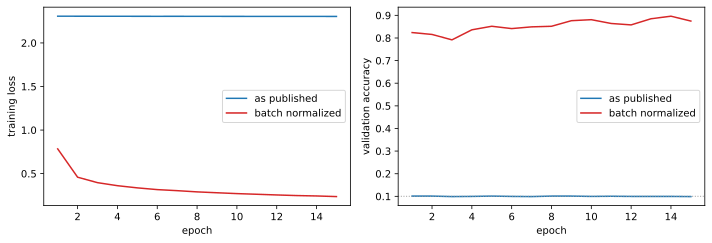

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
epochs_range = range(1, len(plain_loss) + 1)

ax1.plot(epochs_range, plain_loss, color='C0', label='as published')
ax1.plot(epochs_range, bn_loss, color='C3', label='batch normalized')
ax1.set_xlabel('epoch'); ax1.set_ylabel('training loss'); ax1.legend()

ax2.plot(epochs_range, plain_acc, color='C0', label='as published')
ax2.plot(epochs_range, bn_acc, color='C3', label='batch normalized')
ax2.axhline(0.1, color='0.6', linestyle=':', linewidth=1)
ax2.set_xlabel('epoch'); ax2.set_ylabel('validation accuracy'); ax2.legend()
fig.tight_layout()

The plateau is gone, and the sigmoids are untouched.

This is the cleanest evidence in the module that the trouble in 06_06 was never
really about the shape of the sigmoid function.  It was about *scale*: the
sigmoids were saturating because the values arriving at them were too large,
and once each layer's inputs are held near zero mean and unit variance, the same
activation function that stalled for five epochs trains immediately.  ReLU
solves the problem by not saturating; batch normalization solves it by keeping
the inputs in the range where saturation does not arise.  They are different
answers to one question, and modern networks use both.

Let's look at what the first normalization layer learned.

In [13]:
first_bn = bn_model[1]
print('gamma (scale):', first_bn.gamma.reshape(-1).detach().cpu().numpy().round(3))
print('beta  (shift):', first_bn.beta.reshape(-1).detach().cpu().numpy().round(3))
print()
print('running mean :', first_bn.moving_mean.reshape(-1).cpu().numpy().round(3))
print('running var  :', first_bn.moving_var.reshape(-1).cpu().numpy().round(3))

gamma (scale): [2.537 1.98  2.1   1.961 2.446 2.416]
beta  (shift): [ 1.272 -1.096  1.099 -0.496  0.516  0.767]

running mean : [-0.025 -0.355  0.137 -0.172  0.077 -0.093]
running var  : [0.171 0.361 0.123 0.137 0.172 0.204]


The $\boldsymbol{\gamma}$ values have moved away from their initial 1 and the
$\boldsymbol{\beta}$ values away from 0, and they differ per channel: each of
the six feature detectors has settled on its own scale.  The running mean and
variance are the statistics that will be used at prediction time, accumulated
over training and never updated by a gradient.

## The concise version

PyTorch provides `nn.BatchNorm1d` and `nn.BatchNorm2d`, and `nn.LazyBatchNorm2d`
which infers the channel count.  They do what we wrote, faster, with the forward
and backward passes fused.

In [14]:
def make_lenet_concise(num_classes=10):
    """The same network, using PyTorch's batch normalization."""
    return nn.Sequential(
        nn.LazyConv2d(6, kernel_size=5, padding=2), nn.LazyBatchNorm2d(), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.LazyLinear(120), nn.LazyBatchNorm1d(), nn.Sigmoid(),
        nn.LazyLinear(84), nn.LazyBatchNorm1d(), nn.Sigmoid(),
        nn.LazyLinear(num_classes))

torch.manual_seed(0)
_, concise_loss, concise_acc = train(make_lenet_concise(), quiet=True)
print(f'final validation accuracy: {concise_acc[-1]:.3f} '
      f'(from scratch: {bn_acc[-1]:.3f})')

final validation accuracy: 0.874 (from scratch: 0.875)


## Layer normalization

Now back to the row-versus-column picture, because the alternative slice is the
one you have already been using.

Batch normalization's statistics come from the batch, and that dependence causes
real trouble:

* **Small batches give noisy statistics.**  With a batch of 8, the mean and
  variance are poor estimates, and the normalization adds noise rather than
  removing it.  With a batch of 1 the variance is zero and the whole thing is
  undefined.
* **Training and prediction compute different functions**, with all the
  bookkeeping and bugs that follow.
* **Variable-length inputs break it.**  In a batch of sentences of different
  lengths, position 40 exists in three of the sequences and is padding in the
  other twenty-nine.  What is the mean over the batch at position 40?
* **Autoregressive generation breaks it.**  A language model generating one
  token at a time has no batch to normalize over.

Layer normalization takes the perpendicular slice and every one of these
problems disappears:

$$\mathrm{LN}(\mathbf{x}) = \boldsymbol{\gamma} \odot
\frac{\mathbf{x} - \hat{\mu}}{\hat{\sigma}} + \boldsymbol{\beta}$$

where $\hat{\mu}$ and $\hat{\sigma}$ are now computed over the *features of a
single example*.  Each example is normalized entirely on its own.  There is no
batch dependence, so there are no running statistics, no train/eval distinction,
and no minimum batch size.

That is why every transformer uses layer normalization — the `nn.LayerNorm` calls
in the module 04 notebooks that we did not stop to explain.  Text arrives in
variable-length sequences and is generated one token at a time, which rules out
batch normalization on all counts.  Vision models, working on fixed-size images
in large batches, have no such constraint, which is why convolutional networks
went the other way.

Here they are side by side, on the same data.  The last two lines are the point:
change which other examples share the batch, and batch normalization gives a
different answer for the same input.

In [15]:
X = torch.randn(4, 6) * 3 + 5      # (batch, features), deliberately off-scale

bn = nn.BatchNorm1d(6)
ln = nn.LayerNorm(6)

print('input row means    ', X.mean(dim=1).detach().numpy().round(3))
print('input column means ', X.mean(dim=0).detach().numpy().round(3))
print()
print('after batch norm, column means',
      bn(X).mean(dim=0).detach().numpy().round(3), '<- columns standardized')
print('after layer norm, row means   ',
      ln(X).mean(dim=1).detach().numpy().round(3), '<- rows standardized')
print()
# the batch dependence, made concrete: normalize the same example twice,
# once in a batch of two and once in a batch of four
bn.train()
same_under_bn = torch.allclose(bn(X[:2])[0], bn(X)[0], atol=1e-5)
same_under_ln = torch.allclose(ln(X[:2])[0], ln(X)[0], atol=1e-5)
print('batch norm: example 0 unchanged by its batchmates?', same_under_bn)
print('layer norm: example 0 unchanged by its batchmates?', same_under_ln)

input row means     [5.346 2.524 4.928 5.892]
input column means  [3.603 2.935 5.97  2.676 5.56  7.289]

after batch norm, column means [ 0. -0.  0.  0. -0.  0.] <- columns standardized
after layer norm, row means    [ 0.  0. -0.  0.] <- rows standardized

batch norm: example 0 unchanged by its batchmates? False
layer norm: example 0 unchanged by its batchmates? True


## Why does it work?

The title of the paper says "by reducing internal covariate shift", and the
original explanation was that normalization stops the distribution of each
layer's inputs from drifting as the layers below it train.  It is an appealing
story and it is how batch normalization is usually taught.

The evidence does not support it.  Santurkar and colleagues took a
batch-normalized network and *deliberately injected* noisy, shifting
distributions after the normalization layers — reintroducing covariate shift on
purpose — and the networks still trained fast:

> Santurkar, S., Tsipras, D., Ilyas, A., & Madry, A. (2018). How does batch
> normalization help optimization? *Advances in Neural Information Processing
> Systems*, 31.

Their explanation is that normalization makes the loss surface smoother — it
bounds how fast the gradient can change as you move, so a larger step is safe.
That directly predicts the effect practitioners actually rely on: batch
normalized networks tolerate much higher learning rates, which is most of why
they train faster.  Exercise 3 asks you to check this.

There is a second, accidental benefit.  Because each example's normalization
depends on the batch it landed in, an example is scaled slightly differently
every epoch — an injection of noise closely related to what dropout does
deliberately.  Batch normalized networks often need less other regularization,
and networks using batch normalization rarely use dropout in their convolutional
body.

It is worth being clear that this is a technique whose *effectiveness* is not in
doubt and whose *mechanism* is still argued about.  That is more common in deep
learning than the textbooks suggest, and it is a healthier thing to say than a
tidy story that happens to be wrong.

## Summary

* **Batch normalization standardizes each layer's inputs using minibatch
  statistics**, then applies a learned scale $\boldsymbol{\gamma}$ and shift
  $\boldsymbol{\beta}$ so the layer can choose the scale it wants.
* **Fully connected layers normalize per feature; convolutional layers normalize
  per channel**, averaging over batch and both spatial axes, because weight
  sharing makes all positions of a channel measurements of the same quantity.
* **It behaves differently in training and prediction.**  Running estimates of
  the mean and variance, kept as buffers rather than parameters, are used at
  prediction time.  This is what `model.train()` and `model.eval()` control, and
  forgetting the switch is a bug that flatters your results.
* **Inserting it into LeNet removes the plateau of notebook 06_06 without
  changing the activation function**, which shows the original problem was one
  of scale rather than of the sigmoid's shape.
* **Layer normalization takes the perpendicular slice** — over the features of a
  single example — and so has no batch dependence, no running statistics and no
  train/eval distinction.  It is what transformers use, and why.
* **The mechanism is disputed.**  The "internal covariate shift" explanation in
  the paper's title has been tested and largely rejected; the current account is
  that normalization smooths the loss surface and so permits larger steps.

## Exercises

1. **Check the bug.**  Evaluate `bn_model` on the validation set without calling
   `model.eval()` first.  How much does the accuracy change, and in which
   direction?  Explain the sign of the effect.
2. **Remove the bias.**  Set `bias=False` on the convolutional and linear layers
   that are followed by batch normalization and retrain.  Confirm that accuracy
   is unaffected, and say how many parameters you saved.
3. **The learning rate claim.**  Train the plain and batch-normalized LeNets at
   learning rates of 0.01, 0.1, 0.5 and 2.0.  Plot final accuracy against
   learning rate for both.  Which network's usable range is wider, and by how
   much?  This is the practical benefit of batch normalization in one figure.
4. **Batch size dependence.**  Retrain the batch-normalized model with batch
   sizes of 4, 16, 128 and 512, holding everything else fixed.  At which point do
   the noisy statistics start to hurt, and how does this relate to why
   transformers avoid batch normalization?
5. **Swap in layer normalization.**  Replace `BatchNorm` with `nn.LayerNorm` in
   `make_lenet` — note that for a convolutional layer you must give it the full
   `(channels, height, width)` shape. Does it remove the plateau too?  Is it
   better or worse than batch normalization here, and would you expect the same
   answer on a batch of size 4?
6. **Where should it go?**  Move the normalization to *after* the sigmoid instead
   of before it and retrain.  Predict the result first: what does normalizing a
   value that is already confined to $(0, 1)$ accomplish?
7. Rerun the `activation_scales` diagnostic from the top of the notebook with a
   `BatchNorm` inserted after each linear layer.  What happens to the gradient
   column, and how far down the network does the improvement reach?
8. Batch normalization's running statistics are saved in the `state_dict` but are
   not parameters.  Print `bn_model.state_dict().keys()` and identify which
   entries the optimizer never touches.  Why would a checkpoint be useless
   without them?